In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [71]:
upoloaded=files.upload()

Saving spotify-tracks-dataset-detailed.csv to spotify-tracks-dataset-detailed (2).csv


In [72]:
df=pd.read_csv("spotify-tracks-dataset-detailed.csv")
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [73]:
df.shape

(114000, 20)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [75]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [76]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [77]:
df.duplicated().sum()

np.int64(450)

In [78]:
df=df.drop_duplicates()
df.shape

(113550, 20)

In [79]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

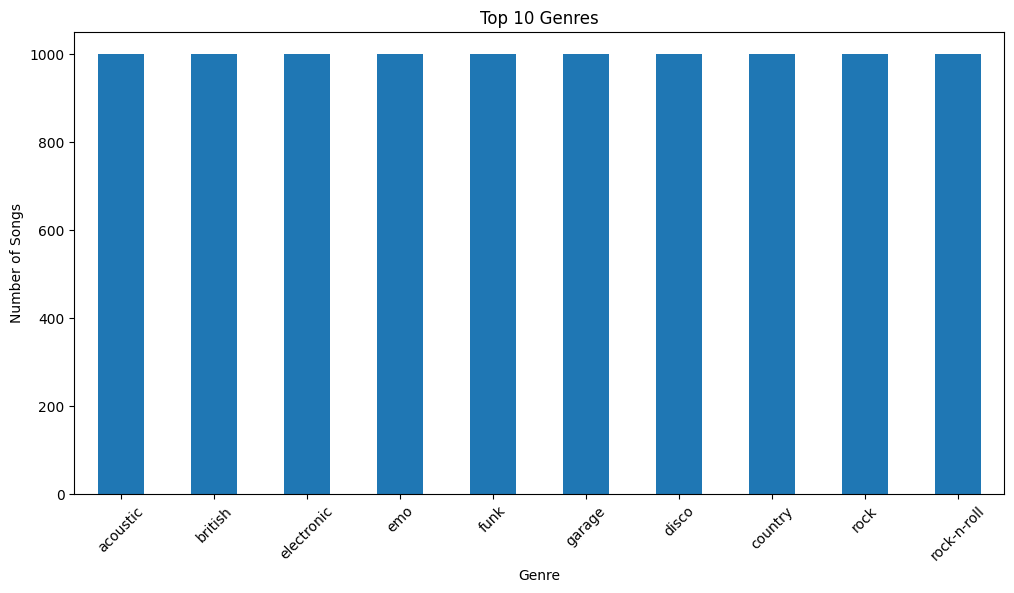

In [80]:
plt.figure(figsize=(12,6))
df["track_genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

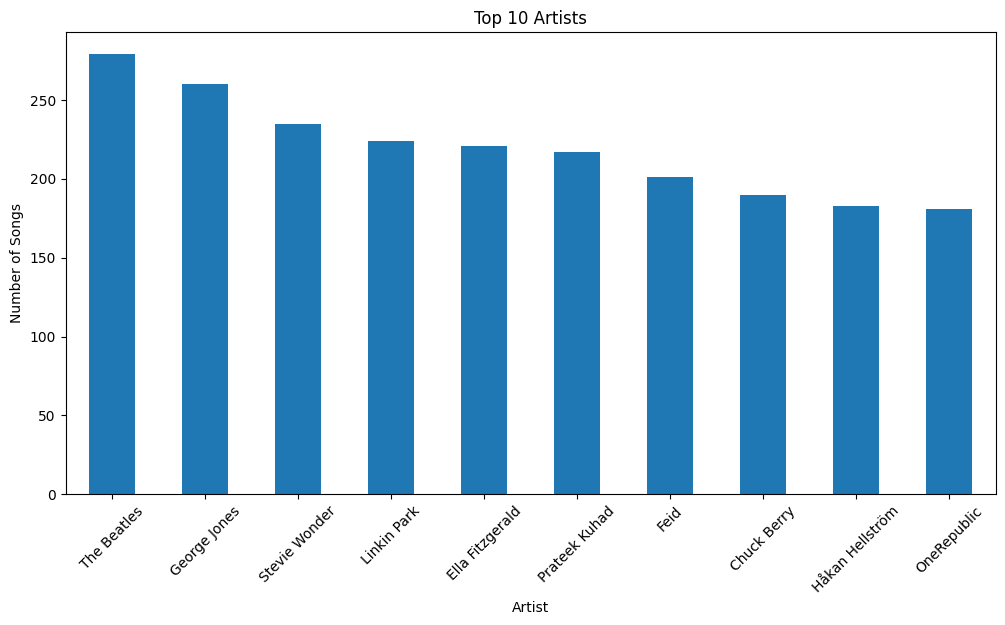

In [81]:
plt.figure(figsize=(12,6))
df["artists"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Artists")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

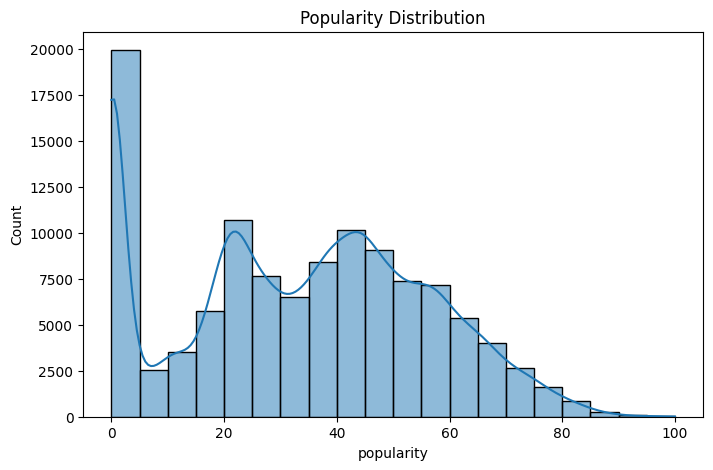

In [82]:
plt.figure(figsize=(8,5))
sns.histplot(df["popularity"],bins=20,kde=True)
plt.title("Popularity Distribution")
plt.show()

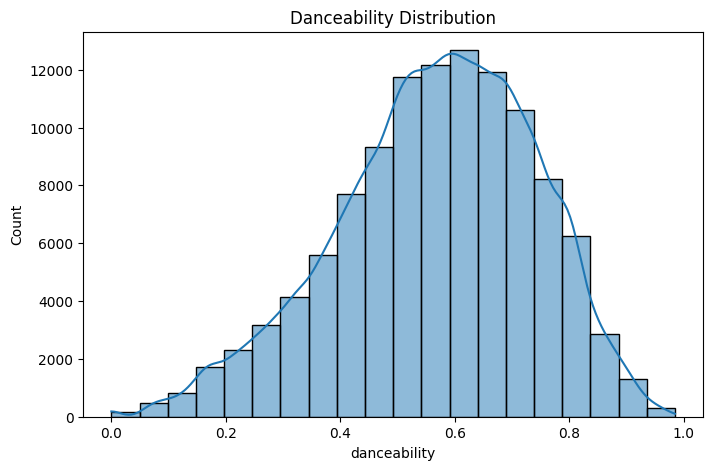

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(df["danceability"],bins=20,kde=True)
plt.title("Danceability Distribution")
plt.show()

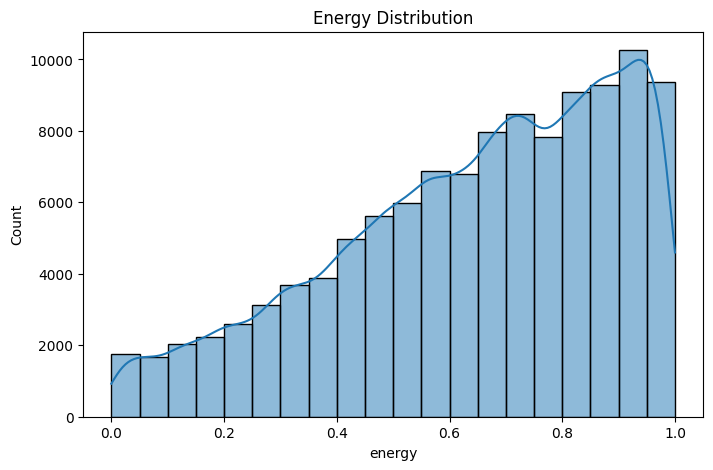

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(df["energy"],bins=20,kde=True)
plt.title("Energy Distribution")
plt.show()

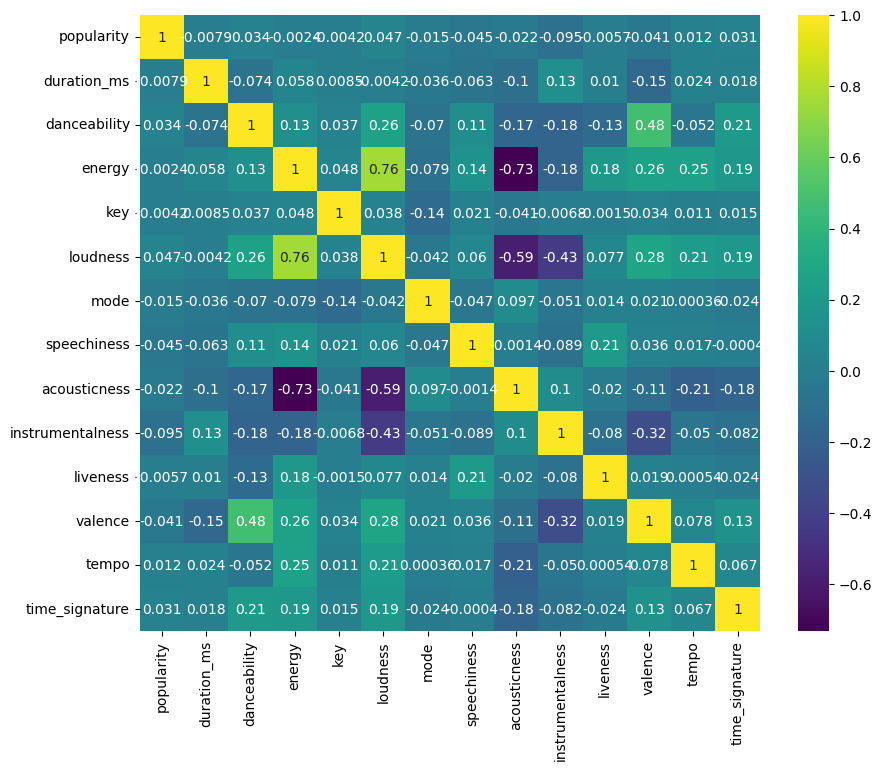

In [85]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="viridis")
plt.show()

In [86]:
import plotly.express as px
fig=px.scatter(
    df.sample(1500,random_state=42),
    x="danceability",
    y="energy",
    color="popularity",
    hover_data=["track_name","artists","track_genre"],
    title="Danceability vs Energy"
)
fig.show()

In [87]:
features=df[[
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]]
features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [88]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)
scaled_features.shape

(113550, 9)

In [89]:
from sklearn.neighbors import NearestNeighbors
model=NearestNeighbors(
    n_neighbors=6,
    metric="cosine"
)
model.fit(scaled_features)

NearestNeighbors(metric='cosine', n_neighbors=6)

In [90]:
indices = df.reset_index().drop_duplicates(subset='track_name', keep='first').set_index('track_name')['index']
indices.head()

,index
track_name,
Comedy,0
Ghost - Acoustic,1
To Begin Again,2
Can't Help Falling In Love,3
Hold On,4


In [91]:
def recommend(song):
    idx=indices[song]
    distances,neighbors=model.kneighbors(
        scaled_features[idx].reshape(1,-1)
    )
    result=df.iloc[neighbors[0][1:]][[
        "track_name",
        "artists",
        "album_name",
        "track_genre",
        "popularity"
    ]]
    return result

In [92]:
recommend(df["track_name"].iloc[0])

,track_name,artists,album_name,track_genre,popularity
102151,Comedy,Gen Hoshino,Comedy,songwriter,73
62102,Comedy,Gen Hoshino,Comedy,j-pop,73
99152,Comedy,Gen Hoshino,Comedy,singer-songwriter,73
111951,Skylight,Gramatik,"Beatz & Pieces, Vol. 1",trip-hop,45
92863,That Certain Female,Charlie Feathers,Kill Bill Vol. 1 Original Soundtrack (PA Version),rockabilly,46


In [93]:
print(scaled_features.shape)
print(type(scaled_features))

(113550, 9)
<class 'numpy.ndarray'>


In [94]:
recommend(df["track_name"].iloc[100])

,track_name,artists,album_name,track_genre,popularity
99901,Rain,Motohiro Hata,言ノ葉,singer-songwriter,58
102901,Rain,Motohiro Hata,言ノ葉,songwriter,58
62255,Rain,Motohiro Hata,言ノ葉,j-pop,58
63105,Rain,Motohiro Hata,言ノ葉,j-rock,58
81182,Nazm Nazm,Arko,Bareilly Ki Barfi,pop,71


In [95]:
def get_recommendations(song):
    if song not in indices:
        return "Song Not Found"
    idx=indices[song]
    distances,neighbors=model.kneighbors(
        scaled_features[idx].reshape(1,-1)
    )
    result=df.iloc[neighbors[0][1:]][[
        "track_name",
        "artists",
        "album_name",
        "track_genre",
        "popularity"
    ]].copy()
    result["Similarity Score"]=(1-distances[0][1:]).round(3)
    return result.reset_index(drop=True)

In [96]:
get_recommendations(df["track_name"].iloc[50])

,track_name,artists,album_name,track_genre,popularity,Similarity Score
0,Trampoline - Acoustic,Highland Peak,Trampoline (Acoustic),chill,46,1.000
1,Dear Theodosia,Leslie Odom Jr.;Lin-Manuel Miranda,Hamilton (Original Broadway Cast Recording),show-tunes,65,0.998
2,為什麼,盧業瑂,關不掉的聲音,cantopop,20,0.997
3,Rise,Boyce Avenue,"Cover Sessions, Vol. 4",acoustic,49,0.993
4,The Bomb,Florence + The Machine,Fall Aesthetic,alternative,0,0.992


In [97]:
import pickle
pickle.dump(model,open("spotify_knn_model.pkl","wb"))
pickle.dump(scaler,open("spotify_scaler.pkl","wb"))
pickle.dump(indices,open("song_indices.pkl","wb"))

In [98]:
!ls

 app.py			 spotify_scaler.pkl
 sample_data		 spotify-songs-eda-andrecommendation-system.ipynb
 song_indices.pkl	'spotify-tracks-dataset-detailed (1).csv'
 spotify_dataset.pkl	'spotify-tracks-dataset-detailed (2).csv'
 spotify_knn_model.pkl	 spotify-tracks-dataset-detailed.csv


In [99]:
import ipywidgets as widgets
from IPython.display import display,clear_output

In [100]:
songs=sorted(df["track_name"].dropna().unique())
song_dropdown=widgets.Dropdown(
    options=songs,
    description="Song",
    layout=widgets.Layout(width="600px")
)
button=widgets.Button(
    description="Recommend Songs",
    button_style="success"
)
output=widgets.Output()

In [101]:
def predict(b):
    with output:
        clear_output()
        result=get_recommendations(song_dropdown.value)
        display(result)
button.on_click(predict)

In [102]:
display(
    song_dropdown,
    button,
    output
)

Dropdown(description='Song', layout=Layout(width='600px'), options=("!I'll Be Back!", '"A" You\'re Adorable', …

Button(button_style='success', description='Recommend Songs', style=ButtonStyle())

Output()

In [103]:
pickle.dump(df,open("spotify_dataset.pkl","wb"))

In [104]:
!ls

 app.py			 spotify_scaler.pkl
 sample_data		 spotify-songs-eda-andrecommendation-system.ipynb
 song_indices.pkl	'spotify-tracks-dataset-detailed (1).csv'
 spotify_dataset.pkl	'spotify-tracks-dataset-detailed (2).csv'
 spotify_knn_model.pkl	 spotify-tracks-dataset-detailed.csv


In [105]:
!pip install -q streamlit

In [106]:
%%writefile app.py

Overwriting app.py


In [107]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px
st.markdown("---")
st.set_page_config(
    page_title="Spotify Song Recommendation System",
    page_icon="🎵",
    layout="wide"
)
st.markdown("""
<style>
.stApp{
background:linear-gradient(to right,#000000,#121212);
color:white;
}
h1,h2,h3,h4,h5,h6,p,label{
color:white;
}
.main-title{
font-size:50px;
font-weight:bold;
text-align:center;
color:#1DB954;
}
.sub-title{
font-size:20px;
text-align:center;
color:white;
margin-bottom:30px;
}
.metric{
background:#181818;
padding:20px;
border-radius:15px;
text-align:center;
box-shadow:0px 0px 10px rgba(29,185,84,0.4);
}
.result-card{
background:#181818;
padding:20px;
border-radius:15px;
margin-bottom:15px;
border-left:6px solid #1DB954;
}
footer{
text-align:center;
color:gray;
margin-top:40px;
}
</style>
""",unsafe_allow_html=True)
st.markdown("<div class='main-title'>🎵 Spotify Song Recommendation System</div>",unsafe_allow_html=True)
st.markdown("<div class='sub-title'>Find songs similar to your favourite tracks using Machine Learning</div>",unsafe_allow_html=True)

Overwriting app.py


In [108]:
%%writefile app.py
import streamlit as st
model=pickle.load(open("spotify_knn_model.pkl","rb"))
scaler=pickle.load(open("spotify_scaler.pkl","rb"))
indices=pickle.load(open("song_indices.pkl","rb"))
df=pickle.load(open("spotify_dataset.pkl","rb"))
features=df[[
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]]
scaled_features=scaler.transform(features)
st.sidebar.image("https://storage.googleapis.com/pr-newsroom-wp/1/2018/11/Spotify_Logo_CMYK_Green.png",width=180)
st.sidebar.title("🎧 Search Song")
song=st.sidebar.selectbox(
    "Choose a Song",
    sorted(df["track_name"].dropna().unique())
)
recommend_button=st.sidebar.button("🎵 Recommend Songs")
st.markdown("---")
c1,c2,c3,c4=st.columns(4)
with c1:
    st.metric("Songs",f"{len(df):,}")
with c2:
    st.metric("Artists",df["artists"].nunique())
with c3:
    st.metric("Genres",df["track_genre"].nunique())
with c4:
    st.metric("Albums",df["album_name"].nunique())
st.markdown("---")

Overwriting app.py


In [109]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px

# Streamlit page configuration and styling
st.markdown("<!-- markdownlint-disable MD033 -->", unsafe_allow_html=True)
st.set_page_config(
    page_title="Spotify Song Recommendation System",
    page_icon="🎵",
    layout="wide"
)
st.markdown("""
<style>
.stApp{
background:linear-gradient(to right,#000000,#121212);
color:white;
}
h1,h2,h3,h4,h5,h6,p,label{
color:white;
}
.main-title{
font-size:50px;
font-weight:bold;
text-align:center;
color:#1DB954;
}
.sub-title{
font-size:20px;
text-align:center;
color:white;
margin-bottom:30px;
}
.metric{
background:#181818;
padding:20px;
border-radius:15px;
text-align:center;
box-shadow:0px 0px 10px rgba(29,185,84,0.4);
}
.result-card{
background:#181818;
padding:20px;
border-radius:15px;
margin-bottom:15px;
border-left:6px solid #1DB954;
}
footer{
text-align:center;
color:gray;
margin-top:40px;
}
</style>
""",unsafe_allow_html=True)
st.markdown("<div class='main-title'>🎵 Spotify Song Recommendation System</div>",unsafe_allow_html=True)
st.markdown("<div class='sub-title'>Find songs similar to your favourite tracks using Machine Learning</div>",unsafe_allow_html=True)
st.markdown("<!-- markdownlint-enable MD033 -->", unsafe_allow_html=True)


# Load models and data
model=pickle.load(open("spotify_knn_model.pkl","rb"))
scaler=pickle.load(open("spotify_scaler.pkl","rb"))
indices=pickle.load(open("song_indices.pkl","rb"))
df=pickle.load(open("spotify_dataset.pkl","rb"))
features=df[[
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]]
scaled_features=scaler.transform(features)


# Define the recommendation function
def get_recommendations(song):
    if song not in indices:
        return "Song Not Found"
    idx=indices[song]
    distances,neighbors=model.kneighbors(
        scaled_features[idx].reshape(1,-1)
    )
    result=df.iloc[neighbors[0][1:]][[
        "track_name",
        "artists",
        "album_name",
        "track_genre",
        "popularity"
    ]].copy()
    result["Similarity Score"]=(1-distances[0][1:]).round(3)
    return result.reset_index(drop=True)


# Streamlit sidebar widgets and metrics
st.sidebar.image("https://storage.googleapis.com/pr-newsroom-wp/1/2018/11/Spotify_Logo_CMYK_Green.png",width=180)
st.sidebar.title("🎧 Search Song")
song=st.sidebar.selectbox(
    "Choose a Song",
    sorted(df["track_name"].dropna().unique())
)
recommend_button=st.sidebar.button("🎵 Recommend Songs")
st.markdown("---")
c1,c2,c3,c4=st.columns(4)
with c1:
    st.metric("Songs",f"{len(df):,}")
with c2:
    st.metric("Artists",df["artists"].nunique())
with c3:
    st.metric("Genres",df["track_genre"].nunique())
with c4:
    st.metric("Albums",df["album_name"].nunique())
st.markdown("---")


# Recommendation display logic
if recommend_button:
    st.subheader("🎵 Recommended Songs")
    recommendations=get_recommendations(song)
    if isinstance(recommendations, str) and recommendations == "Song Not Found":
        st.write("Song Not Found. Please select another song.")
    else:
        for i,row in recommendations.iterrows():
            with st.container():
                st.markdown(f"""
<div style='background:#181818;padding:20px;border-radius:15px;margin-bottom:15px;border-left:5px solid #1DB954;'>
<h3 style='color:#1DB954;'>{row['track_name']}</h3>
<b>Artist</b> : {row['artists']}<br>
<b>Album</b> : {row['album_name']}<br>
<b>Genre</b> : {row['track_genre']}<br>
<b>Popularity</b> : {row['popularity']} ⭐<br>
<b>Similarity</b> : {row['Similarity Score']}
</div>
""",unsafe_allow_html=True)

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦

⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-07-09 12:06:03.881 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.196.189.134:8501



In [ ]:
st.markdown("---")
st.subheader("Spotify Analytics Dashboard")
col1,col2=st.columns(2)
with col1:
    genre=df["track_genre"].value_counts().head(10)
    fig=px.bar(
        x=genre.values,
        y=genre.index,
        orientation="h",
        title="Top 10 Genres"
    )
    fig.update_layout(
        template="plotly_dark",
        height=450
    )
    st.plotly_chart(fig,use_container_width=True)
with col2:
    artist=df["artists"].value_counts().head(10)
    fig=px.bar(
        x=artist.values,
        y=artist.index,
        orientation="h",
        title="Top 10 Artists"
    )
    fig.update_layout(
        template="plotly_dark",
        height=450
    )
    st.plotly_chart(fig,use_container_width=True)
st.markdown("---")
col3,col4=st.columns(2)
with col3:
    fig=px.histogram(
        df,
        x="popularity",
        nbins=30,
        title="Popularity Distribution"
    )
    fig.update_layout(
        template="plotly_dark",
        height=450
    )
    st.plotly_chart(fig,use_container_width=True)
with col4:
    sample=df.sample(1500,random_state=42)
    fig=px.scatter(
        sample,
        x="danceability",
        y="energy",
        color="popularity",
        hover_name="track_name",
        hover_data=["artists","track_genre"],
        title="Danceability vs Energy"
    )
    fig.update_layout(
        template="plotly_dark",
        height=450
    )
    st.plotly_chart(fig,use_container_width=True)